#Task 1. Audio Preprocessing and Visualization

Develop a simple audio preprocessing and visualization notebook that displays different representations of an audio signal before and after preprocessing.

###Dataset

• Use any audio dataset of your choice that is appropriate for the given task

###Tasks

- Load an audio sample from the selected dataset.

- Apply suitable preprocessing such as resampling, normalization, trimming or silence removal.

- Display the waveform, Mel-spectrogram, MFCC heatmap and FFT spectrum.

- Compare the original and preprocessed audio representations.

In [2]:
#import req libs
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

In [6]:
audio_path = librosa.ex("libri1")

audio, sr = librosa.load(
    audio_path,
    sr=None
)

print("Sample Rate :", sr)
print("Number of Samples :", len(audio))
print("Duration :", len(audio)/sr, "seconds")

Sample Rate : 22050
Number of Samples : 327222
Duration : 14.84 seconds


## Original Waveform

The waveform shows how the amplitude of the audio signal changes over time before any preprocessing.

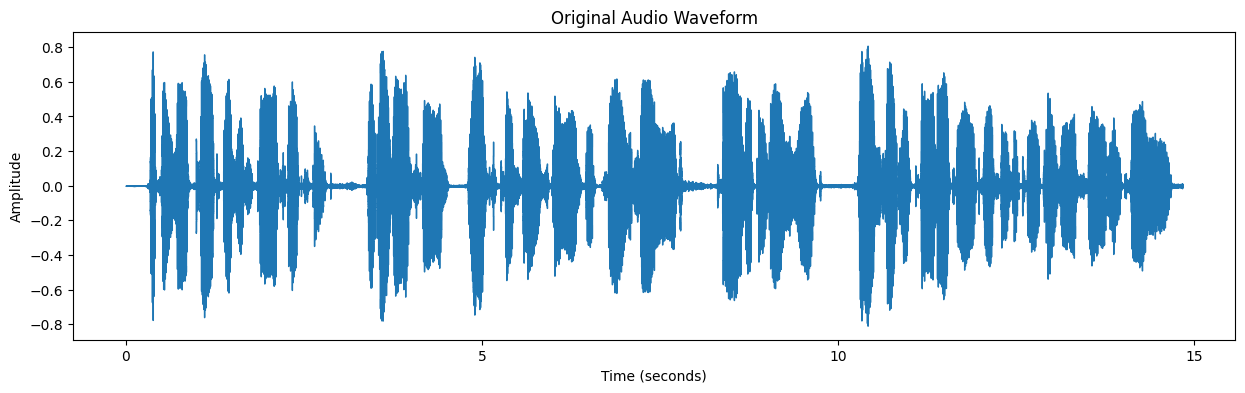

In [7]:
plt.figure(figsize=(15,4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Original Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

## Audio Preprocessing

The following preprocessing steps are applied:

- Normalization
- Silence Removal (Trimming)
- Resampling

In [8]:
# Normalize the audio

normalized_audio = librosa.util.normalize(audio)

print("Normalization completed.")

Normalization completed.


In [9]:
# Remove silence

trimmed_audio, trim_index = librosa.effects.trim(
    normalized_audio
)

print("Silence removed.")

print("Original Samples :", len(normalized_audio))
print("Trimmed Samples  :", len(trimmed_audio))

Silence removed.
Original Samples : 327222
Trimmed Samples  : 326198


In [10]:
# Resample to 16 kHz

target_sr = 16000

processed_audio = librosa.resample(
    trimmed_audio,
    orig_sr=sr,
    target_sr=target_sr
)

print("Original Sample Rate :", sr)
print("New Sample Rate      :", target_sr)

print()

print("Processed Samples :", len(processed_audio))
print("Duration :", len(processed_audio)/target_sr, "seconds")

Original Sample Rate : 22050
New Sample Rate      : 16000

Processed Samples : 236697
Duration : 14.7935625 seconds


## Preprocessing Observation

The audio was successfully preprocessed by applying normalization, silence removal and resampling.

Normalization scaled the audio amplitudes to a consistent range.

Silence removal removed a small number of silent samples from the beginning or end of the recording.

Finally, the audio was resampled from 22050 Hz to 16000 Hz, making it suitable for many speech processing and deep learning models.

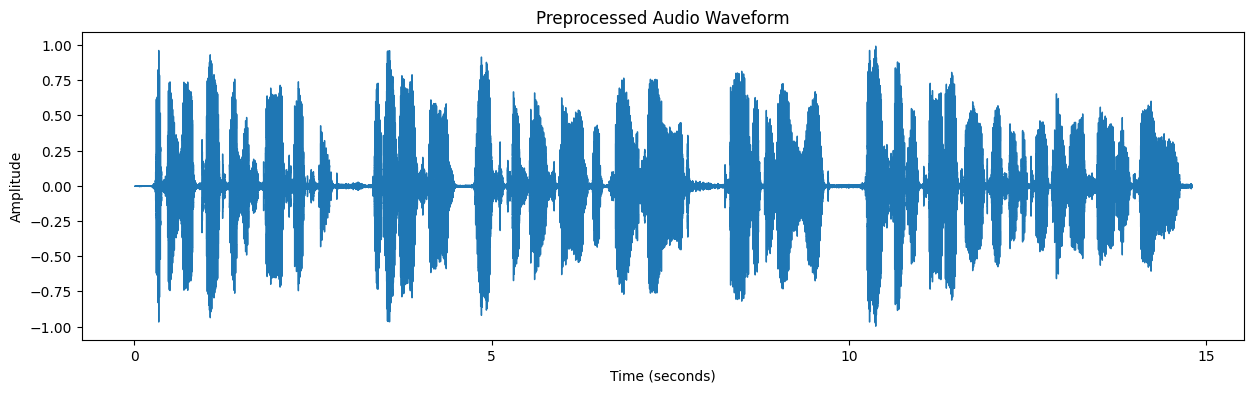

In [11]:
plt.figure(figsize=(15,4))

librosa.display.waveshow(
    processed_audio,
    sr=target_sr
)

plt.title("Preprocessed Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

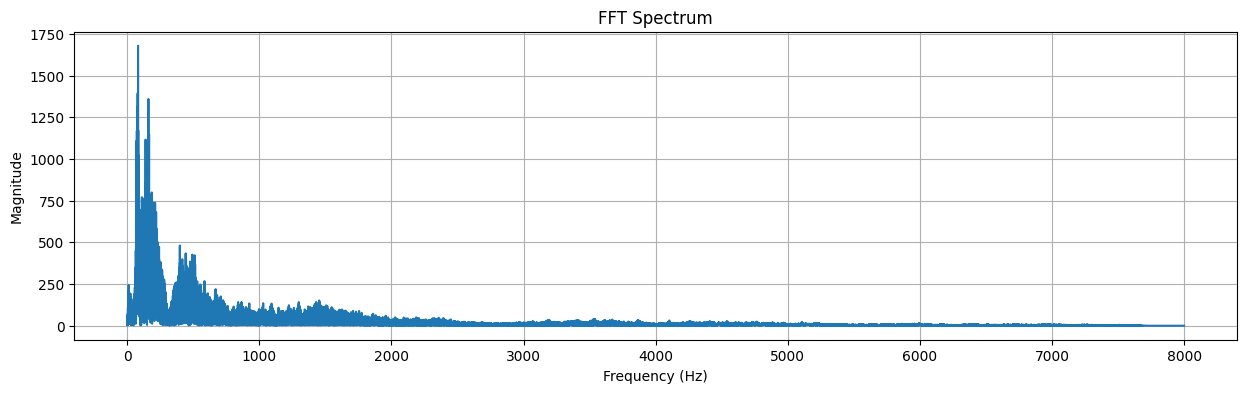

In [12]:
fft = np.fft.fft(processed_audio)

frequencies = np.fft.fftfreq(
    len(fft),
    d=1/target_sr
)

plt.figure(figsize=(15,4))

plt.plot(
    frequencies[:len(frequencies)//2],
    np.abs(fft[:len(fft)//2])
)

plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.grid(True)

plt.show()

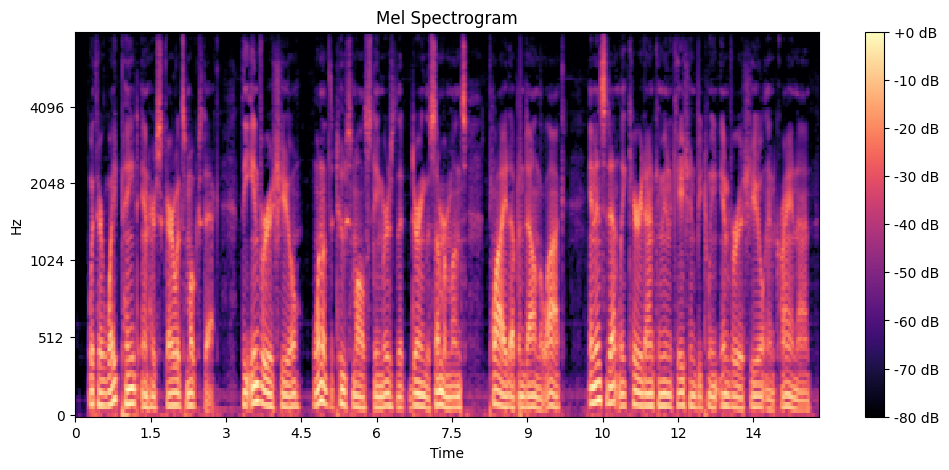

In [13]:
mel_spec = librosa.feature.melspectrogram(
    y=processed_audio,
    sr=target_sr
)

mel_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_db,
    sr=target_sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")

plt.title("Mel Spectrogram")

plt.show()

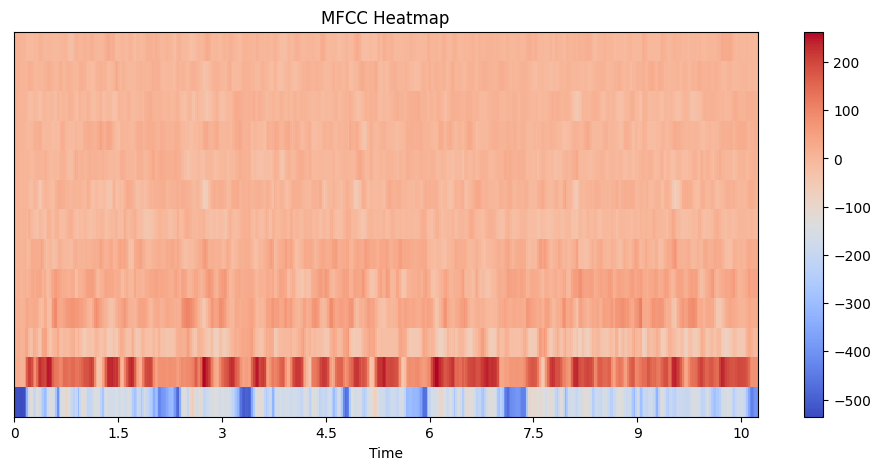

In [14]:
mfcc = librosa.feature.mfcc(
    y=processed_audio,
    sr=target_sr,
    n_mfcc=13
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mfcc,
    x_axis="time"
)

plt.colorbar()

plt.title("MFCC Heatmap")

plt.show()

## Comparison of Original and Preprocessed Audio

The preprocessing steps preserved the important speech information while removing unnecessary silence and converting the audio to the desired sample rate. The waveform shape remains similar, but the processed audio is cleaner and more suitable for further analysis.